# Models training and evaluation

This notebook contains the workflow of training and performance evaluation of different machine learning models on the XCH₄ short-term forecasting dataset previously built. A Ridge model, a default-like Random Forest, and a previously selected regularized Random Forest with larger leaf sizes are evaluated over two temporal validation folds, and compared with each other and with the persistence baseline. The best performing model on the validation folds is then trained on the final multiyear train test and evaluated on the final test set.  

## 1. Opening and exploring the dataframe

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from po_valley_methane_forecasting.paths import find_project_root
from po_valley_methane_forecasting.data_access import (
    load_feature_table,
)
from po_valley_methane_forecasting.models import get_candidate_models
from po_valley_methane_forecasting.validation import (
    build_temporal_fold,
    build_final_train_test_split
)
from po_valley_methane_forecasting.evaluation import (
    evaluate_persistence,
    evaluate_estimator,
    evaluate_models_over_folds,
    comparison_with_baseline,
    summarize_validation_results
)

In [2]:
project_root = find_project_root()

features_path = (
    project_root
    / "data"
    / "processed"
    / "methane_forecasting_features_2019_2024.parquet"
)

model_df = load_feature_table(
    features_path
)

In [3]:
print("Shape:", model_df.shape)
print(model_df.dtypes)
model_df.head()

Shape: (175411, 14)
week                datetime64[ns]
target_week         datetime64[ns]
cell_id                      int64
x                          float64
y                          float64
CH4                        float32
ch4_prev_1w                float32
ch4_prev_2w                float32
ch4_change_1w              float32
ch4_mean_last_3w           float64
ch4_std_last_3w            float64
season_sin                 float64
season_cos                 float64
target_next_week           float32
dtype: object


,week,target_week,cell_id,x,y,CH4,ch4_prev_1w,ch4_prev_2w,ch4_change_1w,ch4_mean_last_3w,ch4_std_last_3w,season_sin,season_cos,target_next_week
0,2019-01-13,2019-01-20,39,12.056052,44.356250,1846.231689,1852.413086,1869.556030,-6.181396,1856.066935,12.083840,0.239316,0.970942,1854.096802
1,2019-01-13,2019-01-20,43,7.527282,44.390972,1854.673462,1828.253418,1868.875977,26.420044,1850.600952,20.615214,0.239316,0.970942,1835.700928
2,2019-01-13,2019-01-20,44,7.581845,44.390972,1854.673462,1830.136230,1859.465576,24.537231,1848.091756,15.733460,0.239316,0.970942,1835.700928
3,2019-01-13,2019-01-20,45,7.636409,44.390972,1845.013428,1830.136230,1859.465576,14.877197,1844.871745,14.665186,0.239316,0.970942,1835.700928
4,2019-01-13,2019-01-20,46,7.690972,44.390972,1845.013428,1830.887939,1843.886841,14.125488,1839.929403,7.850372,0.239316,0.970942,1835.700928


In [4]:
print("Rows:", len(model_df))
print("Cells:", model_df["cell_id"].nunique())
print("Feature weeks:", model_df["week"].nunique())
print("Target weeks:", model_df["target_week"].nunique())

print(
    "Feature period:",
    model_df["week"].min(),
    "→",
    model_df["week"].max(),
)

print(
    "Target period:",
    model_df["target_week"].min(),
    "→",
    model_df["target_week"].max(),
)

Rows: 175411
Cells: 2615
Feature weeks: 270
Target weeks: 270
Feature period: 2019-01-13 00:00:00 → 2024-12-22 00:00:00
Target period: 2019-01-20 00:00:00 → 2024-12-29 00:00:00


In [5]:
feature_columns = [
    "CH4",
    "ch4_prev_1w",
    "ch4_prev_2w",
    "ch4_change_1w",
    "ch4_mean_last_3w",
    "ch4_std_last_3w",
    "x",
    "y",
    "season_sin",
    "season_cos",
]

target_column = "target_next_week"

In [6]:
required_columns = feature_columns + [target_column]

assert model_df[required_columns].notna().all().all()

print("No missing values in model features or target.")

No missing values in model features or target.


In [7]:
model_df["target_year"] = (
    model_df["target_week"].dt.year
)

In [8]:
annual_summary = (
    model_df
    .groupby("target_year")
    .agg(
        rows=("target_next_week", "size"),
        target_weeks=("target_week", "nunique"),
        cells=("cell_id", "nunique"),
    )
    .reset_index()
)

development_target_stats = (
    model_df.loc[
        model_df["target_year"] <= 2023
    ]
    .groupby("target_year")
    .agg(
        mean_target=("target_next_week", "mean"),
        std_target=("target_next_week", "std"),
    )
    .reset_index()
)

annual_summary = annual_summary.merge(
    development_target_stats,
    on="target_year",
    how="left",
)

annual_summary

,target_year,rows,target_weeks,cells,mean_target,std_target
0,2019,36148,47,2522,1855.531128,13.487836
1,2020,30324,43,2563,1870.640869,17.122662
2,2021,23158,49,2484,1885.078735,19.701859
3,2022,32435,44,2564,1893.982544,15.272194
4,2023,26870,42,2573,1906.071045,18.894072
5,2024,26476,45,2581,NaN,NaN


## 2. Preparing temporal folds for machine learning

In [9]:
validation_folds = [
    {
        "name": "Validation 2022",
        "train_end_year": 2021,
        "validation_year": 2022,
    },
    {
        "name": "Validation 2023",
        "train_end_year": 2022,
        "validation_year": 2023,
    },
]

In [10]:
for fold in validation_folds:
    train_fold_df, validation_fold_df = (
        build_temporal_fold(
            dataframe=model_df,
            train_end_year=fold["train_end_year"],
            validation_year=fold["validation_year"],
        )
    )

    print(f'\n{fold["name"]}')
    print("-" * len(fold["name"]))

    print(
        "Training target period:",
        train_fold_df["target_week"].min(),
        "→",
        train_fold_df["target_week"].max(),
    )

    print(
        "Validation target period:",
        validation_fold_df["target_week"].min(),
        "→",
        validation_fold_df["target_week"].max(),
    )

    print("Training rows:", len(train_fold_df))
    print("Validation rows:", len(validation_fold_df))


Validation 2022
---------------
Training target period: 2019-01-20 00:00:00 → 2021-12-26 00:00:00
Validation target period: 2022-01-02 00:00:00 → 2022-12-11 00:00:00
Training rows: 89630
Validation rows: 32435

Validation 2023
---------------
Training target period: 2019-01-20 00:00:00 → 2022-12-11 00:00:00
Validation target period: 2023-01-22 00:00:00 → 2023-12-31 00:00:00
Training rows: 122065
Validation rows: 26870


In [ ]:
final_train_df, test_df = build_final_train_test_split(
    dataframe=model_df,
    test_year=2024
)

In [24]:
print(
    "Final training target period:",
    final_train_df["target_week"].min(),
    "→",
    final_train_df["target_week"].max(),
)

print(
    "Test target period:",
    test_df["target_week"].min(),
    "→",
    test_df["target_week"].max(),
)

print("Final training rows:", len(final_train_df))
print("Test rows:", len(test_df))

Final training target period: 2019-01-20 00:00:00 → 2023-12-31 00:00:00
Test target period: 2024-01-07 00:00:00 → 2024-12-29 00:00:00
Final training rows: 148935
Test rows: 26476


## 3. Training and comparing different models on validation folds

In [ ]:
candidate_models = get_candidate_models()

In [ ]:
fold_results_df = evaluate_models_over_folds(
    dataframe=model_df,
    validation_folds=validation_folds,
    candidate_models=candidate_models,
    feature_columns=feature_columns,
    target_column=target_column,
    persistence_column="CH4",
)

In [33]:
display_columns = [
    "fold",
    "model",
    "train_MAE",
    "validation_mean_error",
    "validation_MAE",
    "validation_RMSE",
    "validation_R2",
    "validation_prediction_std",
    "validation_correlation",
]

fold_comparison_df = (
    fold_results_df[display_columns]
    .sort_values(
        ["fold", "validation_MAE"]
    )
    .reset_index(drop=True)
)

In [34]:
fold_comparison_df

,fold,model,train_MAE,validation_mean_error,validation_MAE,validation_RMSE,validation_R2,validation_prediction_std,validation_correlation
0,Validation 2022,Ridge,10.523725,5.935767,11.127994,14.455700,0.104040,9.322458,0.514170
1,Validation 2022,Persistence,NaN,0.407320,12.401623,16.263741,-0.134100,14.668440,0.410802
2,Validation 2022,Random Forest — regularized,6.359402,9.713838,13.105424,16.469125,-0.162925,11.099017,0.529627
3,Validation 2022,Random Forest — default,1.647037,11.571429,15.434431,19.276983,-0.593267,14.329392,0.458924
4,Validation 2023,Ridge,10.458801,5.036008,12.207919,15.668575,0.312260,12.854730,0.621874
5,Validation 2023,Persistence,NaN,-1.110147,14.374695,18.420781,0.049437,17.716920,0.497058
6,Validation 2023,Random Forest — regularized,6.417810,9.400566,14.439929,18.101766,0.082076,9.427906,0.579792
7,Validation 2023,Random Forest — default,1.667468,9.411156,14.969370,18.672104,0.023322,10.907191,0.523740


In [ ]:
comparison_with_baseline_df = comparison_with_baseline(fold_results_df)

In [38]:
baseline_comparison_columns = [
    "fold",
    "model",
    "validation_MAE",
    "MAE_improvement_over_persistence_pct",
    "validation_RMSE",
    "RMSE_improvement_over_persistence_pct",
    "validation_R2",
]

comparison_with_baseline_df[
        baseline_comparison_columns
    ]

,fold,model,validation_MAE,MAE_improvement_over_persistence_pct,validation_RMSE,RMSE_improvement_over_persistence_pct,validation_R2
0,Validation 2022,Ridge,11.127994,10.269852,14.455700,11.117001,0.104040
1,Validation 2022,Persistence,12.401623,0.000000,16.263741,0.000000,-0.134100
2,Validation 2022,Random Forest — regularized,13.105424,-5.675074,16.469125,-1.262837,-0.162925
3,Validation 2022,Random Forest — default,15.434431,-24.454934,19.276983,-18.527365,-0.593267
4,Validation 2023,Ridge,12.207919,15.073543,15.668575,14.940765,0.312260
5,Validation 2023,Persistence,14.374695,0.000000,18.420781,0.000000,0.049437
6,Validation 2023,Random Forest — regularized,14.439929,-0.453810,18.101766,1.731822,0.082076
7,Validation 2023,Random Forest — default,14.969370,-4.136961,18.672104,-1.364347,0.023322


In [ ]:
validation_summary_df = summarize_validation_results(comparison_with_baseline_df)

In [42]:
validation_summary_df

,model,mean_validation_MAE,std_validation_MAE,worst_validation_MAE,mean_validation_RMSE,std_validation_RMSE,mean_validation_R2,mean_MAE_improvement_pct,mean_prediction_correlation
0,Ridge,11.667957,0.763622,12.207919,15.062138,0.857632,0.208150,12.671698,0.568022
1,Persistence,13.388159,1.395173,14.374695,17.342261,1.525258,-0.042332,0.000000,0.453930
2,Random Forest — regularized,13.772676,0.943637,14.439929,17.285445,1.154451,-0.040425,-3.064442,0.554710
3,Random Forest — default,15.201901,0.328848,15.434431,18.974544,0.427714,-0.284973,-14.295947,0.491332


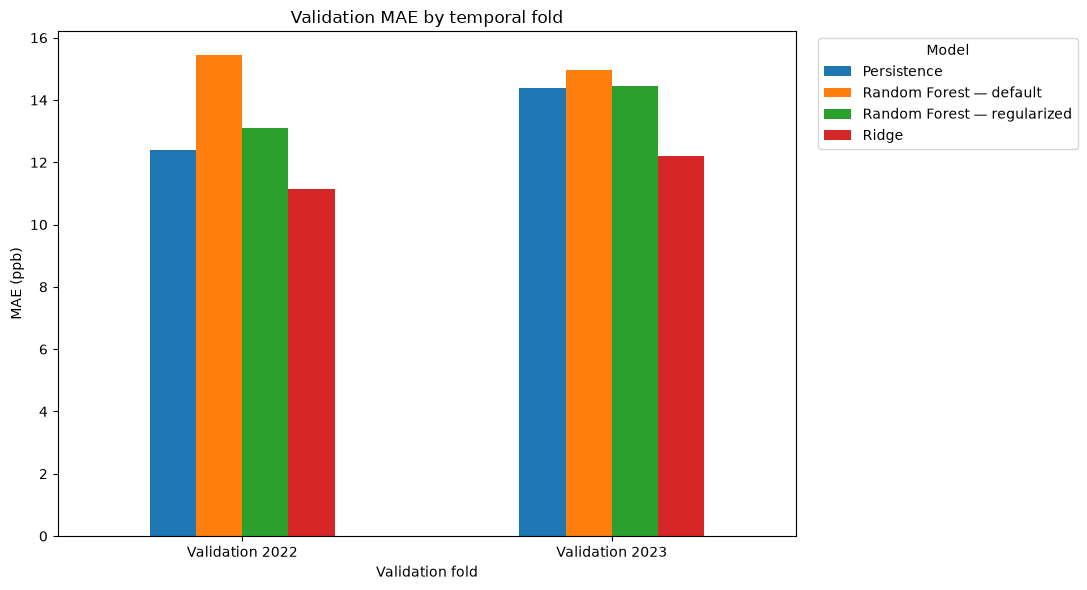

In [45]:
mae_by_fold = (
    fold_results_df
    .pivot(
        index="fold",
        columns="model",
        values="validation_MAE",
    )
)

mae_by_fold.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.title(
    "Validation MAE by temporal fold"
)
plt.xlabel("Validation fold")
plt.ylabel("MAE (ppb)")
plt.xticks(rotation=0)
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

The validation results show that Ridge is the only candidate model that consistently improves over the persistence baseline across both temporal folds. This suggests that a regularized linear combination of recent XCH₄ history, spatial information, and seasonal features provides useful predictive information beyond the current-week observation. This predictive relationship should not be interpreted as a causal or intrinsically linear physical dependence.

## 4. Ridge final training and evaluation

In [ ]:
final_evaluation = evaluate_estimator(
    base_model=candidate_models["Ridge"],
    train_df=final_train_df,
    evaluation_df=test_df,
    feature_columns=feature_columns,
    target_column=target_column,
)

selected_model = final_evaluation["model"]
final_predictions = (
    final_evaluation["evaluation_predictions"]
)
final_metrics = (
    final_evaluation["evaluation_metrics"]
)

final_metrics

In [ ]:
(
    final_persistence_metrics,
    final_persistence_predictions,
) = evaluate_persistence(
    evaluation_df=test_df,
    target_column=target_column,
    persistence_column="CH4",
)

final_persistence_metrics

In [49]:
final_mae_improvement = (
    final_persistence_metrics["MAE"]
    - final_metrics["MAE"]
) / final_persistence_metrics["MAE"] * 100

final_rmse_improvement = (
    final_persistence_metrics["RMSE"]
    - final_metrics["RMSE"]
) / final_persistence_metrics["RMSE"] * 100

print(
    "Ridge MAE improvement over persistence:",
    f"{final_mae_improvement:.2f}%"
)

print(
    "Ridge RMSE improvement over persistence:",
    f"{final_rmse_improvement:.2f}%"
)

Ridge MAE improvement over persistence: 9.07%
Ridge RMSE improvement over persistence: 7.40%


In [50]:
final_comparison_df = pd.DataFrame([
    {
        "model": "Persistence",
        **final_persistence_metrics,
    },
    {
        "model": "Ridge",
        **final_metrics,
    },
])

final_comparison_df[
    [
        "model",
        "mean_error",
        "MAE",
        "RMSE",
        "R2",
        "prediction_std",
        "correlation",
    ]
]

,model,mean_error,MAE,RMSE,R2,prediction_std,correlation
0,Persistence,0.865776,16.220643,21.245858,0.018069,20.769970,0.494532
1,Ridge,3.991208,14.749186,19.673392,0.158041,14.876011,0.485777


In [53]:
ridge_estimator = selected_model.named_steps["ridge"]

ridge_coefficients = (
    pd.Series(
        ridge_estimator.coef_,
        index=feature_columns,
        name="standardized_coefficient",
    )
    .sort_values(
        key=np.abs,
        ascending=False,
    )
)

ridge_coefficients

CH4                 5.677859
ch4_mean_last_3w    5.606734
ch4_prev_1w         5.406628
ch4_prev_2w         4.350538
season_sin         -1.762824
season_cos         -0.957428
ch4_std_last_3w     0.716003
ch4_change_1w       0.619815
x                   0.537859
y                   0.038074
Name: standardized_coefficient, dtype: float64

The above table and the following graph show the relative predictive contribution of the different features within the fitted linear model.

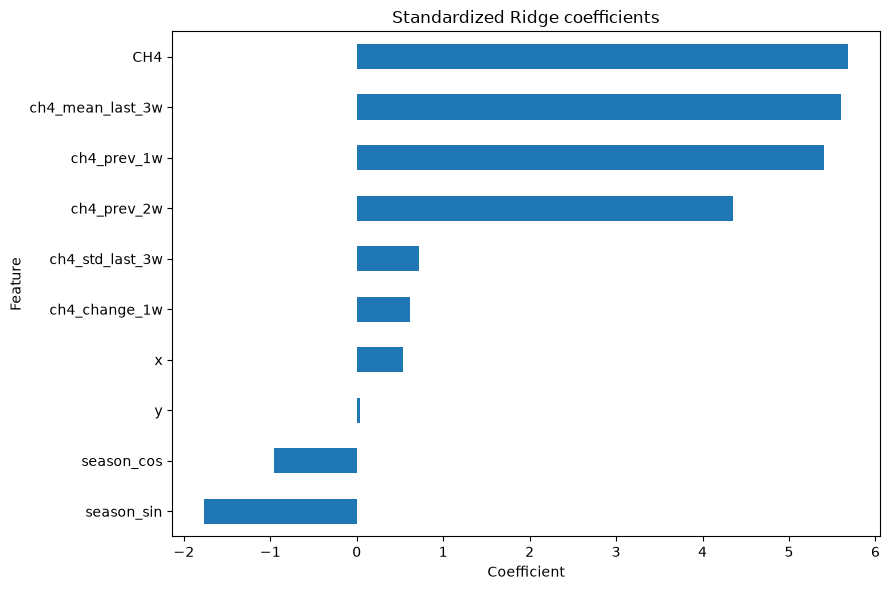

In [54]:
ridge_coefficients.sort_values().plot(
    kind="barh",
    figsize=(9, 6),
)

plt.title("Standardized Ridge coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

On the held-out 2024 test set, Ridge achieves a MAE of 14.75 ppb and a RMSE of 19.67 ppb, improving over persistence by approximately 9.1% and 7.4%, respectively. Absolute errors are higher than in the validation folds, but the model retains a modest out-of-sample advantage over the persistence baseline.